In [ ]:
import pandas as pd

df = pd.read_excel(r'C:\Users\mamun\OneDrive\Desktop\BDREN-Project\smartsales-ml\data\row\online_retail_II.xlsx')

# Remove missing customers
df = df[df['Customer ID'].notna()]

# Remove cancelled invoices
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove invalid quantities
df = df[df['Quantity'] > 0]

# Remove invalid prices
df = df[df['Price'] > 0]

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create revenue column
df['Revenue'] = df['Quantity'] * df['Price']

print(df.shape)
print(df.head())

(511565, 9)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  Revenue  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom     83.4  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom    100.8  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom     30.0  


In [1]:
import pandas as pd

In [14]:
data=pd.read_csv(r'..\data\row\online_retail_II_2010_2011.csv', encoding='ISO-8859-1')


In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [16]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/09 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/09 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/09 7:45,1.25,13085.0,United Kingdom


In [17]:
data.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [18]:
data.dropna(subset=['Customer ID'], inplace=True)

In [19]:
data.info()

<class 'pandas.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      824364 non-null  str    
 1   StockCode    824364 non-null  str    
 2   Description  824364 non-null  str    
 3   Quantity     824364 non-null  int64  
 4   InvoiceDate  824364 non-null  str    
 5   Price        824364 non-null  float64
 6   Customer ID  824364 non-null  float64
 7   Country      824364 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 56.6 MB


In [20]:
data[data['Invoice'].astype(str).str.startswith('C')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,12/1/09 10:33,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,12/1/09 10:33,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,12/1/09 10:33,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,12/1/09 10:33,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,12/1/09 10:33,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/11 9:57,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,12/9/11 10:28,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/11 11:57,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/11 11:58,1.25,17315.0,United Kingdom


In [21]:
data=data[~data['Invoice'].astype(str).str.startswith('C')]

In [22]:
data[data["Quantity"].le(0)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [23]:
data[data["Price"]<=0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,12/2/09 13:34,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,12/3/09 11:19,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,12/7/09 16:38,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,12/8/09 15:25,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,12/8/09 15:25,0.0,14108.0,United Kingdom
...,...,...,...,...,...,...,...,...
1004540,577129,22464,HANGING METAL HEART LANTERN,4,11/17/11 19:52,0.0,15602.0,United Kingdom
1005014,577168,M,Manual,1,11/18/11 10:42,0.0,12603.0,Germany
1006110,577314,23407,SET OF 2 TRAYS HOME SWEET HOME,2,11/18/11 13:23,0.0,12444.0,Norway
1011446,577696,M,Manual,1,11/21/11 11:57,0.0,16406.0,United Kingdom


In [24]:
data=data[~data['Price'].le(0)]

In [25]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/09 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/09 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/09 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/09 7:45,1.25,13085.0,United Kingdom


In [26]:
data.info()

<class 'pandas.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      805549 non-null  str    
 1   StockCode    805549 non-null  str    
 2   Description  805549 non-null  str    
 3   Quantity     805549 non-null  int64  
 4   InvoiceDate  805549 non-null  str    
 5   Price        805549 non-null  float64
 6   Customer ID  805549 non-null  float64
 7   Country      805549 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 55.3 MB


In [27]:
data.duplicated().sum()

np.int64(26124)

In [28]:
data.drop_duplicates(inplace=True)

In [29]:
data.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  str    
 1   StockCode    779425 non-null  str    
 2   Description  779425 non-null  str    
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  str    
 5   Price        779425 non-null  float64
 6   Customer ID  779425 non-null  float64
 7   Country      779425 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 53.5 MB


In [30]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

C:\Users\mamun\AppData\Local\Temp\ipykernel_172\1740368120.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])


In [31]:
import pandas as pd

reference_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

In [32]:
data['Revenue'] = data['Quantity'] * data['Price']

In [33]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [36]:
data['InvoiceDate']=data['InvoiceDate'].astype('datetime64[ns]')

In [40]:
data.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  str           
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
 8   Revenue      779425 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), str(4)
memory usage: 59.5 MB


In [39]:
data.to_csv(r"..\\data\\processed\\processed_data.csv", index=False)

In [42]:
country_revenue = data.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print(country_revenue.head(10))

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'United Kingdom'),
  Text(1, 0, 'EIRE'),
  Text(2, 0, 'Netherlands'),
  Text(3, 0, 'Germany'),
  Text(4, 0, 'France'),
  Text(5, 0, 'Australia'),
  Text(6, 0, 'Spain'),
  Text(7, 0, 'Switzerland'),
  Text(8, 0, 'Sweden'),
  Text(9, 0, 'Denmark')])

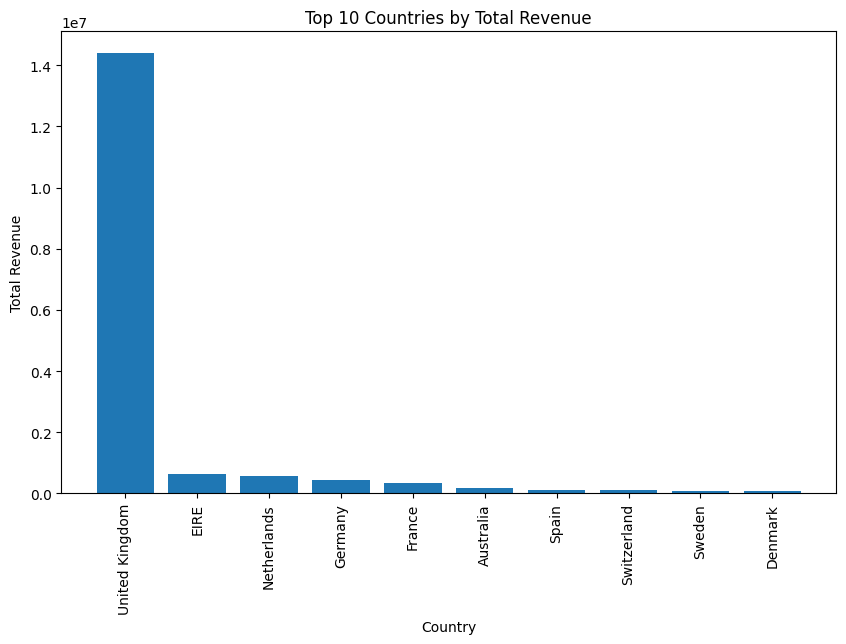

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(country_revenue.index[:10], country_revenue.values[:10])
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.title('Top 10 Countries by Total Revenue')
plt.xticks(rotation=90)

In [45]:
top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
print(top_products.head(10))

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64


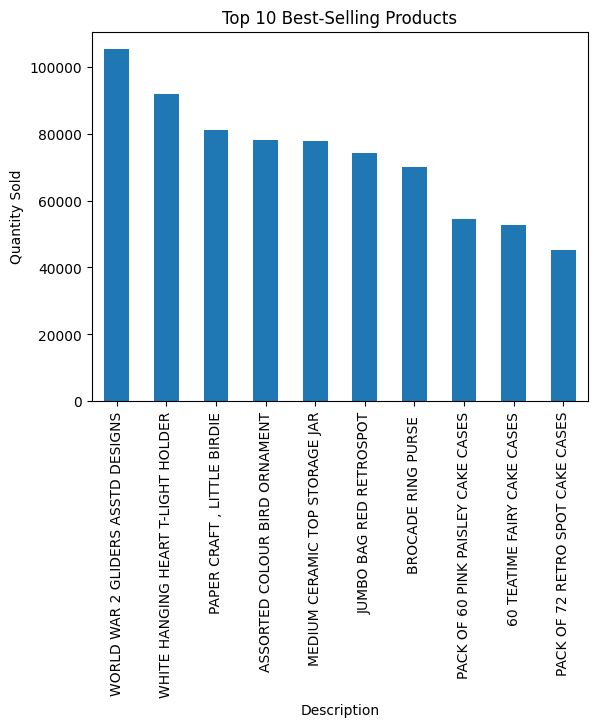

In [46]:
top_products.head(10).plot(kind='bar')
plt.title("Top 10 Best-Selling Products")
plt.ylabel("Quantity Sold")
plt.show()

In [48]:
data['Date'] = data['InvoiceDate'].dt.date
daily_sales = data.groupby('Date')['Revenue'].sum()

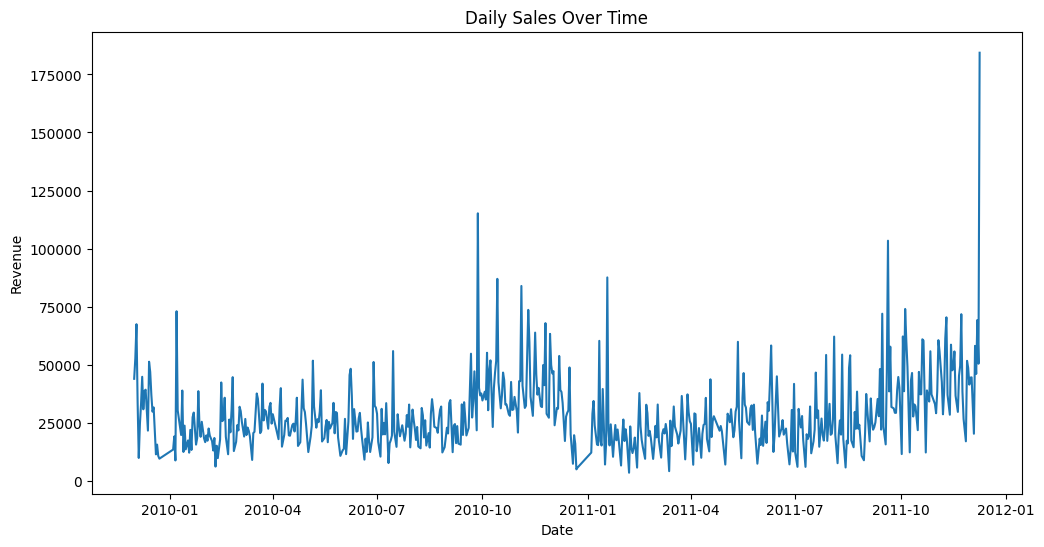

In [49]:
daily_sales.plot(figsize=(12, 6))
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")  
plt.show()

In [50]:
top_customers = data.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
print(top_customers.head(10))

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64


Text(0, 0.5, 'Total Revenue')

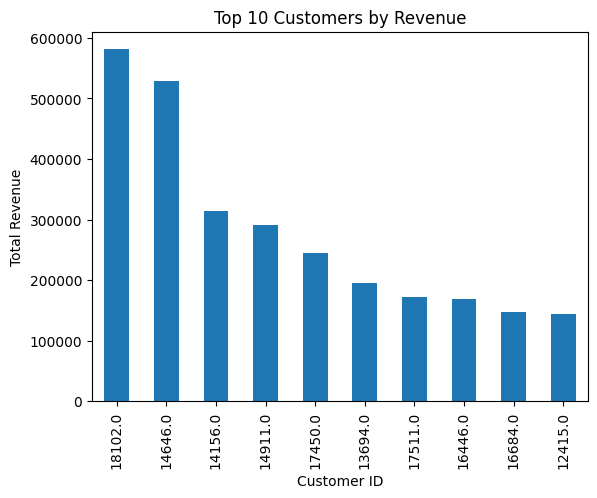

In [51]:
top_customers.head(10).plot(kind='bar')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Revenue")

In [54]:
customer_frequency = data.groupby('Customer ID')['Invoice'].nunique().sort_values(ascending=False)
print(customer_frequency.head(10))


Customer ID
14911.0    398
12748.0    336
17841.0    211
15311.0    208
13089.0    203
14606.0    192
14156.0    156
17850.0    155
14646.0    151
18102.0    145
Name: Invoice, dtype: int64


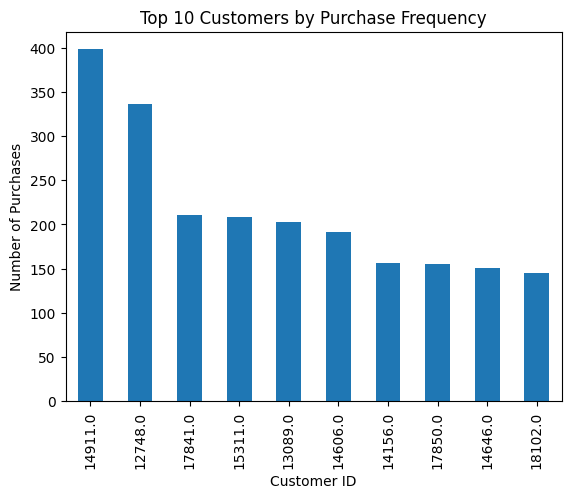

In [55]:
customer_frequency.head(10).plot(kind='bar')
plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Customer ID")
plt.ylabel("Number of Purchases")
plt.show()